# R1 — LLM-judge calibration pilot

**Purpose (SPEC d35).** The Strategy Router's labeling stage needs an
LLM-as-judge for the 15.7K deferred-lane rows (no qrels) and for hole-
filling on the 34K qrels-lane rows. R1's job is to decide *which
model* to use for that judge — measured against known human qrels.

**Method.** Sample 500 (query, doc) pairs from TREC-DL 2022 stratified
equal per graded relevance level (125 per grade × 4 grades). Judge each
pair with Claude Haiku 4.5 and Claude Sonnet 4.6 (same 500 pairs, same
prompt, one pair per call). Compute Cohen's kappa against human grades
(with 1000-resample bootstrap CI) and per-level accuracy. Pick the
cheapest model that clears **kappa ≥ 0.6 AND every per-level accuracy
≥ 70%**.

**Cost.** ~500 × 2 = 1,000 API calls. With prompt caching on the
guidelines, expected total < $1.

**Prerequisites.**

```bash
export ANTHROPIC_API_KEY=...            # your key
```

The first cell will fail loudly without it. Judgments and sampled pairs
are disk-cached (`data/r1_pilot/`), so re-running the notebook after a
kernel restart costs nothing.

In [13]:
import os
import warnings
warnings.filterwarnings("ignore")

from concurrent.futures import ThreadPoolExecutor, as_completed
from hashlib import sha1
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from anthropic import Anthropic
from IPython.display import Markdown, display
from tqdm.auto import tqdm

from hybrid_search_rrf_dataset.judge import (
    HAIKU_4_5,
    PROMPT,
    PROMPT_FEW_SHOT,
    SONNET_4_6,
    LLMJudgment,
    judge,
)


def show_table(df: pd.DataFrame) -> None:
    """Render a DataFrame as a markdown table (portable outside Jupyter)."""
    display(Markdown(df.to_markdown(index=False)))


if not os.environ.get("ANTHROPIC_API_KEY"):
    raise RuntimeError(
        "Set ANTHROPIC_API_KEY in the environment before running this notebook."
    )

CACHE = Path("data/r1_pilot")
CACHE.mkdir(parents=True, exist_ok=True)
PROMPT_HASH = sha1(PROMPT.encode()).hexdigest()[:12]
print(f"prompt hash: {PROMPT_HASH}  (any change invalidates the judgment cache)")

prompt hash: d7c78b93e5de  (any change invalidates the judgment cache)


## 1 — Load TREC-DL 2022 queries + qrels

Routed through `TrecDL2022` (in `hybrid_search_rrf_dataset.retrieval`) so
this pilot's data plumbing matches the rest of the codebase. The class's
`load_metadata()` reads only queries + qrels via ir_datasets — cheap, no
corpus touch; the corpus lookup lives in a separate method (`fetch_docs`)
that we call below with only the sampled doc_ids.

In [16]:
from hybrid_search_rrf_dataset.retrieval import TrecDL2022

trec = TrecDL2022()   # corpus_limit not needed for the targeted-lookup path
trec.load_metadata()
qrels = trec.qrels()
queries = trec.queries()
print(f"queries: {len(queries):,}  |  qrels: {len(qrels):,}")
print("relevance distribution:")
qrels["relevance"].value_counts().sort_index()

queries: 500  |  qrels: 386,416
relevance distribution:


relevance
0    286459
1     52218
2     46080
3      1659
Name: count, dtype: int64

## 2 — Stratified sample: `total` pairs, equal per grade

`stratified_sample()` is a pure function of qrels + queries: change the
`TOTAL` knob for a cheaper first pass (say 60 pairs, ~15 per grade) or
the full 500 R1 sample. Disk cache is keyed by `total`, so switching
sizes doesn't collide with earlier caches — reload freely.

In [17]:
def stratified_sample(
    qrels: pd.DataFrame,
    queries: pd.DataFrame,
    total: int,
    grades: tuple[int, ...] = (0, 1, 2, 3),
    seed: int = 0,
) -> pd.DataFrame:
    """Return `total` pairs stratified equal across `grades`; query text
    merged in, `doc_text` initialized to NA (populated by `attach_doc_texts`).
    If a grade has less supply than `total // len(grades)`, take all of it
    — the returned frame may be smaller than requested."""
    rng = np.random.default_rng(seed)
    per_grade = total // len(grades)
    parts = []
    for grade in grades:
        pool = qrels[qrels["relevance"] == grade]
        take = min(per_grade, len(pool))
        idx = rng.choice(len(pool), size=take, replace=False)
        parts.append(pool.iloc[sorted(idx)])
    sampled = pd.concat(parts, ignore_index=True).merge(queries, on="query_id")
    sampled["doc_text"] = pd.NA
    return sampled


TOTAL = 500          # try 60 or 200 for a cheaper first pass
SAMPLE_PATH = CACHE / f"sampled_pairs_{TOTAL}.parquet"

if SAMPLE_PATH.exists():
    sampled = pd.read_parquet(SAMPLE_PATH)
    print(f"sampled loaded from cache: {len(sampled):,} pairs")
else:
    sampled = stratified_sample(qrels, queries, total=TOTAL)
    print(f"sampled: {len(sampled):,} pairs")
    sampled.to_parquet(SAMPLE_PATH, index=False)

sampled["relevance"].value_counts().sort_index()

sampled loaded from cache: 500 pairs


relevance
0    125
1    125
2    125
3    125
Name: count, dtype: int64

## 3 — Fetch doc texts (early-termination iteration)

Iterate the msmarco-passage-v2 corpus and pull only the ~500 docs we
need; terminate as soon as we've found them all. Order is arbitrary in
`ir_datasets`, so the wall-clock varies — a first run typically takes
10–30 minutes depending on where the sampled doc_ids land. Cached to
disk afterward so subsequent runs are instant.

In [18]:
def attach_doc_texts(
    sampled: pd.DataFrame,
    trec: TrecDL2022,
) -> pd.DataFrame:
    """Fill missing `doc_text` values via `trec.fetch_docs` (targeted
    corpus iteration with early termination). In-place mutation of the
    doc_text column; returns the same frame for chaining."""
    needed = sampled[sampled["doc_text"].isna()]
    if not len(needed):
        return sampled
    print(f"fetching {len(needed):,} doc texts via TrecDL2022.fetch_docs...")
    found = trec.fetch_docs(needed["doc_id"].tolist())
    sampled["doc_text"] = sampled["doc_id"].map(found).fillna(sampled["doc_text"])
    missing = int(sampled["doc_text"].isna().sum())
    assert missing == 0, f"still missing {missing} doc texts — corpus drift?"
    return sampled


sampled = attach_doc_texts(sampled, trec)
sampled.to_parquet(SAMPLE_PATH, index=False)
sampled[["query_id", "doc_id", "relevance", "text", "doc_text"]].head(3)

,query_id,doc_id,relevance,text,doc_text
0,2000511,msmarco_passage_36_67147515,0,average bahamas temperature at the end of october,"For reference, on June 21, the longest day of ..."
1,2000719,msmarco_passage_00_456645026,0,business architect role definition,Five-Year Accounting Program with Senior-Year ...
2,2000719,msmarco_passage_02_445378581,0,business architect role definition,"Ham, sliced, regular (approximately 11% fat) N..."


## 4 — Judgment cache

A tiny disk-backed dict keyed by `(model_id, prompt_hash, query_id,
doc_id)`. Any prompt change invalidates every cached judgment — cost
of correctness for a pinned-prompt regime.

In [19]:
import pickle


class JudgmentCache:
    """Persistent cache of LLM judgments so re-running the notebook does
    not repay the API. One pickle per model; atomic tmp-then-rename."""

    def __init__(self, cache_dir: Path, prompt_hash: str) -> None:
        self.cache_dir = cache_dir
        self.prompt_hash = prompt_hash
        self._store: dict[str, dict[tuple[str, str], LLMJudgment]] = {}

    def _path(self, model_id: str) -> Path:
        return self.cache_dir / f"judgments.{self.prompt_hash}.{model_id}.pkl"

    def load(self, model_id: str) -> dict[tuple[str, str], LLMJudgment]:
        if model_id in self._store:
            return self._store[model_id]
        path = self._path(model_id)
        if path.exists():
            with path.open("rb") as f:
                data = pickle.load(f)
        else:
            data = {}
        self._store[model_id] = data
        return data

    def save(self, model_id: str) -> None:
        path = self._path(model_id)
        tmp = path.with_suffix(path.suffix + ".tmp")
        with tmp.open("wb") as f:
            pickle.dump(self._store[model_id], f)
        tmp.replace(path)


cache = JudgmentCache(CACHE, PROMPT_HASH)

## 5 — Batch judge

Ten concurrent requests. Each call sends the pinned prompt as a cached
system block, so after the first ~2 calls the guidelines are cached
and every subsequent input is ~90% cheaper.

In [20]:
def run_model(
    model_id: str,
    pairs: pd.DataFrame,
    *,
    prompt: str = PROMPT,
    prompt_tag: str = "base",
    max_workers: int = 10,
) -> pd.Series:
    """Judge every row of `pairs` with `model_id` and `prompt`; returns
    LLMJudgment Series aligned with `pairs.index`. `prompt_tag` scopes
    the disk cache so PROMPT vs PROMPT_FEW_SHOT judgments never collide
    on the same (query, doc) key."""
    cache_key = f"{prompt_tag}:{model_id}"
    store = cache.load(cache_key)
    client = Anthropic()

    def one(row_tuple):
        idx, row = row_tuple
        key = (row["query_id"], row["doc_id"])
        if key in store:
            return idx, store[key]
        result = judge(
            row["text"], row["doc_text"], model_id,
            client=client, prompt=prompt,
        )
        store[key] = result
        return idx, result

    todo = [
        rt for rt in pairs.iterrows()
        if (rt[1]["query_id"], rt[1]["doc_id"]) not in store
    ]
    print(f"{prompt_tag}:{model_id}: "
          f"{len(pairs) - len(todo):,} cached, {len(todo):,} to judge")

    # Batch of 50 items: pool joins between batches so the cache save
    # never races against a live writer thread. Same crash-safety
    # (worst case: 50 lost) without threading primitives.
    SAVE_EVERY = 50
    if todo:
        with tqdm(total=len(todo),
                  desc=f"{prompt_tag}:{model_id.split('-')[1]}") as bar:
            for start in range(0, len(todo), SAVE_EVERY):
                batch = todo[start:start + SAVE_EVERY]
                with ThreadPoolExecutor(max_workers=max_workers) as pool:
                    futures = [pool.submit(one, rt) for rt in batch]
                    for fut in as_completed(futures):
                        fut.result()      # raises on API error after SDK retries
                        bar.update(1)
                cache.save(cache_key)     # all batch threads joined — safe

    return pd.Series(
        [store[(r["query_id"], r["doc_id"])] for _, r in pairs.iterrows()],
        index=pairs.index,
    )

## 6 — Run Haiku 4.5

Expected: ~$0.20, ~2 minutes on first run, seconds afterward.

In [23]:
haiku_judgments = run_model(HAIKU_4_5, sampled, prompt=PROMPT_FEW_SHOT, prompt_tag='few_shots')
sampled["haiku_grade"] = [j.grade for j in haiku_judgments]
sampled["haiku_justification"] = [j.justification for j in haiku_judgments]
sampled[["relevance", "haiku_grade"]].value_counts().sort_index().head(16)

few_shots:claude-haiku-4-5-20251001: 0 cached, 500 to judge


few_shots:haiku: 100%|██████████| 500/500 [01:22<00:00,  6.08it/s]


relevance  haiku_grade
0          0              122
           1                3
1          0              101
           1               17
           2                5
           3                2
2          0              111
           1                7
           2                5
           3                2
3          0                7
           1               36
           2               50
           3               32
Name: count, dtype: int64

## 7 — Run Sonnet 4.6

Expected: ~$0.60, ~5 minutes on first run.

In [25]:
sonnet_judgments = run_model(SONNET_4_6, sampled, prompt=PROMPT_FEW_SHOT, prompt_tag='few_shots')
sampled["sonnet_grade"] = [j.grade for j in sonnet_judgments]
sampled["sonnet_justification"] = [j.justification for j in sonnet_judgments]
sampled[["relevance", "sonnet_grade"]].value_counts().sort_index().head(16)

few_shots:claude-sonnet-4-6: 0 cached, 500 to judge


few_shots:sonnet: 100%|██████████| 500/500 [02:13<00:00,  3.74it/s]


relevance  sonnet_grade
0          0               117
           1                 8
1          0               102
           1                15
           2                 8
2          0               110
           1                 7
           2                 7
           3                 1
3          0                 7
           1                33
           2                54
           3                31
Name: count, dtype: int64

## 8 — Metrics: kappa (+ bootstrap CI) and per-level accuracy

Cohen's kappa is computed by hand (5 lines of numpy) — no sklearn
dependency. Chance-adjusted so the "everyone predicts grade 0" trivial
baseline scores 0. Bootstrap resamples the 500 pairs 1000 times with
replacement to give a 95% CI on kappa.

In [26]:
def cohen_kappa(y_true: np.ndarray, y_pred: np.ndarray, k: int = 4) -> float:
    conf = np.zeros((k, k), dtype=float)
    for t, p in zip(y_true, y_pred):
        conf[int(t), int(p)] += 1
    n = conf.sum()
    if n == 0:
        return 0.0
    p_o = np.trace(conf) / n
    p_e = ((conf.sum(axis=0) / n) * (conf.sum(axis=1) / n)).sum()
    if p_e >= 1.0:
        return 0.0
    return (p_o - p_e) / (1 - p_e)


def bootstrap_kappa_ci(y_true: np.ndarray, y_pred: np.ndarray,
                       n_boot: int = 1000, seed: int = 0) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    n = len(y_true)
    ks = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        ks[i] = cohen_kappa(y_true[idx], y_pred[idx])
    return float(np.percentile(ks, 2.5)), float(np.percentile(ks, 97.5))


def per_level_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> dict[int, float]:
    return {
        level: float((y_pred[y_true == level] == level).mean())
        for level in (0, 1, 2, 3)
        if (y_true == level).any()
    }


def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    kappa = cohen_kappa(y_true, y_pred)
    ci_lo, ci_hi = bootstrap_kappa_ci(y_true, y_pred)
    per_level = per_level_accuracy(y_true, y_pred)
    return {
        "model": name,
        "kappa": round(kappa, 3),
        "kappa_95ci": f"[{ci_lo:.3f}, {ci_hi:.3f}]",
        **{f"acc@{k}": round(v, 3) for k, v in per_level.items()},
        "min_per_level": round(min(per_level.values()), 3),
    }


In [27]:
true = sampled["relevance"].to_numpy()
haiku_pred = sampled["haiku_grade"].to_numpy()
sonnet_pred = sampled["sonnet_grade"].to_numpy()

report = pd.DataFrame([
    evaluate("Haiku 4.5", true, haiku_pred),
    evaluate("Sonnet 4.6", true, sonnet_pred),
])
show_table(report)

| model      |   kappa | kappa_95ci     |   acc@0 |   acc@1 |   acc@2 |   acc@3 |   min_per_level |
|:-----------|--------:|:---------------|--------:|--------:|--------:|--------:|----------------:|
| Haiku 4.5  |   0.136 | [0.095, 0.181] |   0.976 |   0.136 |   0.04  |   0.256 |           0.04  |
| Sonnet 4.6 |   0.12  | [0.080, 0.161] |   0.936 |   0.12  |   0.056 |   0.248 |           0.056 |

## 9 — Confusion matrices

Rows are human grades, columns are model grades. Diagonal = agreement.
Off-diagonals show *which way* the model errs — off-by-one is the
common failure and much less serious than swapping 0 with 3.

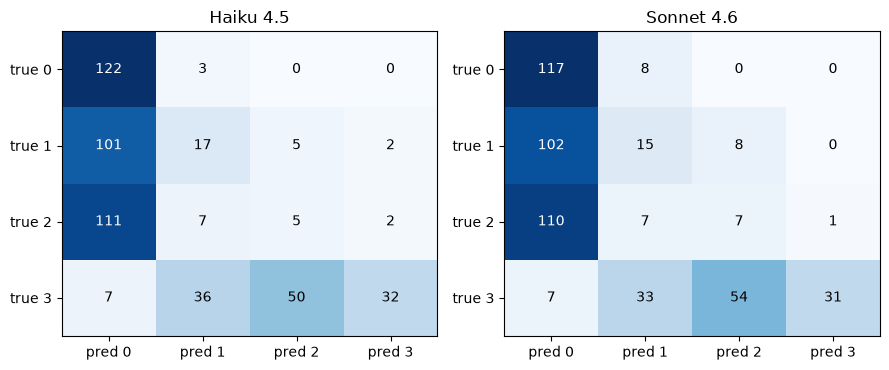

In [28]:
def confusion(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    m = np.zeros((4, 4), dtype=int)
    for t, p in zip(y_true, y_pred):
        m[int(t), int(p)] += 1
    return m


def plot_confusion(ax, m: np.ndarray, title: str) -> None:
    ax.imshow(m, cmap="Blues", aspect="auto")
    for i in range(4):
        for j in range(4):
            colour = "white" if m[i, j] > m.max() * 0.5 else "black"
            ax.text(j, i, str(m[i, j]), ha="center", va="center",
                    fontsize=10, color=colour)
    ax.set_xticks(range(4), [f"pred {k}" for k in range(4)])
    ax.set_yticks(range(4), [f"true {k}" for k in range(4)])
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
plot_confusion(axes[0], confusion(true, haiku_pred), "Haiku 4.5")
plot_confusion(axes[1], confusion(true, sonnet_pred), "Sonnet 4.6")
plt.tight_layout(); plt.show()

## 10 — Decision rule

Per SPEC d35: pick the cheapest model that clears **kappa ≥ 0.6 AND
every per-level accuracy ≥ 70%**. If neither passes, escalate to prompt
iteration (own follow-up session).

In [29]:
KAPPA_MIN = 0.60
PER_LEVEL_MIN = 0.70

MODEL_ID_BY_NAME = {"Haiku 4.5": HAIKU_4_5, "Sonnet 4.6": SONNET_4_6}
APPROX_COST_PER_1K = {"Haiku 4.5": 0.20, "Sonnet 4.6": 0.60}


def verdict(row: dict) -> str:
    if row["kappa"] < KAPPA_MIN:
        return f"FAIL: kappa {row['kappa']} < {KAPPA_MIN}"
    if row["min_per_level"] < PER_LEVEL_MIN:
        return f"FAIL: min per-level acc {row['min_per_level']} < {PER_LEVEL_MIN}"
    return "PASS"


report["verdict"] = report.apply(verdict, axis=1)
report["approx_cost_1k_calls_usd"] = report["model"].map(APPROX_COST_PER_1K)

passing = report[report["verdict"] == "PASS"].sort_values("approx_cost_1k_calls_usd")
if passing.empty:
    print("NO MODEL PASSED — escalate to prompt iteration below (few-shot).")
    picked = None
else:
    picked = passing.iloc[0]
    print(f"PICKED (base prompt): {picked['model']} "
          f"(kappa {picked['kappa']} {picked['kappa_95ci']}, "
          f"min-per-level {picked['min_per_level']}, "
          f"~${picked['approx_cost_1k_calls_usd']}/1k calls)")

show_table(report)

NO MODEL PASSED — escalate to prompt iteration below (few-shot).


| model      |   kappa | kappa_95ci     |   acc@0 |   acc@1 |   acc@2 |   acc@3 |   min_per_level | verdict                 |   approx_cost_1k_calls_usd |
|:-----------|--------:|:---------------|--------:|--------:|--------:|--------:|----------------:|:------------------------|---------------------------:|
| Haiku 4.5  |   0.136 | [0.095, 0.181] |   0.976 |   0.136 |   0.04  |   0.256 |           0.04  | FAIL: kappa 0.136 < 0.6 |                        0.2 |
| Sonnet 4.6 |   0.12  | [0.080, 0.161] |   0.936 |   0.12  |   0.056 |   0.248 |           0.056 | FAIL: kappa 0.12 < 0.6  |                        0.6 |

In [30]:
cache._store

{'base:claude-haiku-4-5-20251001': {('2000719',
   'msmarco_passage_12_714537877'): LLMJudgment(grade=0, justification='The passage is about ranking large banks in Arizona and has nothing to do with defining the business architect role.'),
  ('2000719',
   'msmarco_passage_07_323900799'): LLMJudgment(grade=0, justification='The passage is about COBRA health insurance and has nothing to do with the definition of a business architect role.'),
  ('2000719',
   'msmarco_passage_20_147622143'): LLMJudgment(grade=0, justification="The passage is about a children's animated television series and has no connection to the definition or role of a business architect."),
  ('2000511',
   'msmarco_passage_36_67147515'): LLMJudgment(grade=0, justification='The passage discusses sunrise and sunset times on specific dates but contains no information about Bahamas temperature or October weather conditions.'),
  ('2000719',
   'msmarco_passage_27_206737963'): LLMJudgment(grade=0, justification='The pass

## 12 — Cross-domain diagnostic: msmarco-passage-dev (SPEC d36c)

**Diagnostic only** — not a pass/fail gate. Purpose: hypothesize how
the picked judge will generalize to the labeling stage's non-TREC
domains. If the picked judge collapses here (say < 60%), the labeling
stage's per-cell hole gate (d30d) will need to catch domain-specific
label unreliability — a follow-up grill, not a pilot rejection.

Sampling: 200 random (query, judged_doc) pairs from
`msmarco-passage-dev` qrels — sparse binary qrels, so only human-
labeled *relevant* pairs are available. Metric: positive-agreement
rate = fraction where the picked judge's collapsed grade
({2,3}→relevant) matches the human `relevant` label.

In [ ]:
from hybrid_search_rrf_dataset.retrieval import MSMarcoDev

DIAG_TOTAL = 200
DIAG_PATH = CACHE / f"msmarco_diagnostic_{DIAG_TOTAL}.parquet"

if DIAG_PATH.exists():
    diag = pd.read_parquet(DIAG_PATH)
    print(f"diagnostic pairs loaded from cache: {len(diag):,}")
else:
    msmarco = MSMarcoDev()
    msmarco.load_metadata()
    ms_qrels, ms_queries = msmarco.qrels(), msmarco.queries()
    diag = (
        ms_qrels.sample(n=DIAG_TOTAL, random_state=0)
        .reset_index(drop=True)
        .merge(ms_queries, on="query_id")
    )
    diag["doc_text"] = diag["doc_id"].map(
        msmarco.fetch_docs(diag["doc_id"].tolist())
    )
    assert not diag["doc_text"].isna().any(), "msmarco docs missing"
    diag.to_parquet(DIAG_PATH, index=False)
    print(f"diagnostic pairs: {len(diag):,}")


def bootstrap_rate_ci(mask: np.ndarray, n_boot: int = 1000,
                      seed: int = 0) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    n = len(mask)
    rates = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        rates[i] = mask[idx].mean()
    return float(np.percentile(rates, 2.5)), float(np.percentile(rates, 97.5))


if picked_final is not None:
    diag_j = run_model(
        picked_model_id, diag,
        prompt=picked_prompt,
        prompt_tag=f"diag:{picked_prompt_tag}",
    )
    diag["grade"] = [j.grade for j in diag_j]
    diag["agrees"] = diag["grade"].isin([2, 3]).astype(int)
    rate = float(diag["agrees"].mean())
    ci_lo, ci_hi = bootstrap_rate_ci(diag["agrees"].to_numpy())
    print(f"cross-domain positive-agreement rate: {rate:.3f} "
          f"[95% CI {ci_lo:.3f}, {ci_hi:.3f}]  "
          f"(n={len(diag)}, msmarco-passage-dev, "
          f"model={picked_final['model']})")
    if rate < 0.60:
        print("\n⚠ diagnostic below 60% — grill domain-specific prompt work "
              "before shipping (d30d hole-gate territory).")
    else:
        print("\n✓ diagnostic healthy — labeling stage can proceed with "
              "the picked judge as its default.")
else:
    print("skipping: no model passed calibration.")

## Handoff

The picked (model_id, prompt) tuple + this notebook's kappa/per-level
numbers + the cross-domain diagnostic feed the labeling stage. The
pinned judge-config artifact (`{model_id, prompt_hash, kappa,
per_level_acc, ci, cross_domain_agreement, pilot_date}`) is deferred
to R2's schema-pin work — for now the labeling stage imports directly:

```python
from hybrid_search_rrf_dataset.judge import judge, PROMPT_FEW_SHOT, HAIKU_4_5
grade = judge(query, doc, HAIKU_4_5, prompt=PROMPT_FEW_SHOT)
```

Escalation ladder (all paths covered by SPEC d35 + d36):

1. **Base prompt passes** → ship the picked model with `PROMPT`.
2. **Base fails, few-shot passes** → ship the few-shot variant.
3. **Both fail** → real-exemplar ablation via `build_fewshot_prompt` —
   sample real TREC-DL judgments (different seed than the calibration
   set), pass them in. Own follow-up grill.
4. **Cross-domain diagnostic collapses** — regardless of pilot verdict,
   grill domain-specific prompt work (d30d hole-gate territory).